In [1]:
# Install latest diffusers from GitHub
!pip install -q git+https://github.com/huggingface/diffusers
!pip install transformers accelerate datasets torchvision
!pip install bitsandbytes  # For memory optimization

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00


In [2]:
# Check version
import diffusers
print(f"Diffusers version: {diffusers.__version__}")

Diffusers version: 0.38.0.dev0


In [3]:
# Clone diffusers repo to get training scripts
!git clone https://github.com/huggingface/diffusers.git
%cd diffusers/examples/text_to_image

Cloning into 'diffusers'...
remote: Enumerating objects: 120296, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 120296 (delta 59), reused 32 (delta 32), pack-reused 120201 (from 2)
Receiving objects: 100% (120296/120296), 93.49 MiB | 26.85 MiB/s, done.
Resolving deltas: 100% (89613/89613), done.
/content/diffusers/examples/text_to_image


In [4]:
# Install requirements for training
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


In [5]:
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load Naruto dataset
dataset = load_dataset("lambdalabs/naruto-blip-captions", split="train")

print(f"Dataset size: {len(dataset)} images")
print(f"Features: {dataset.features}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/897 [00:00<?, ?B/s]

data/train-00000-of-00002-12944970063701(…):   0%|          | 0.00/344M [00:00<?, ?B/s]

data/train-00001-of-00002-cefa2f480689f1(…):   0%|          | 0.00/357M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1221 [00:00<?, ? examples/s]

Dataset size: 1221 images
Features: {'image': Image(mode=None, decode=True), 'text': Value('string')}


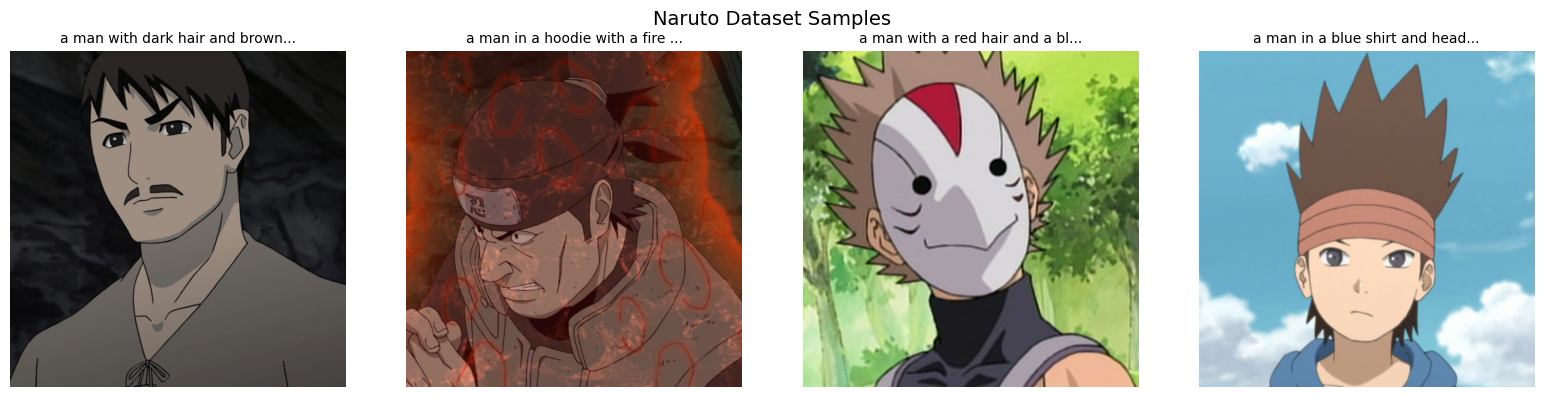

In [13]:
# Show 4 samples
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
    img = dataset[i]["image"]
    caption = dataset[i]["text"]

    axes[i].imshow(img)
    axes[i].set_title(caption[:30] + "...", fontsize=10)
    axes[i].axis("off")

plt.suptitle("Naruto Dataset Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Setup accelerate with default config
!accelerate config default

accelerate configuration saved at /root/.cache/huggingface/accelerate/default_config.yaml


In [17]:
# Launch training!
!accelerate launch train_text_to_image.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --dataset_name="lambdalabs/naruto-blip-captions" \
  --use_ema \
  --resolution=512 --center_crop --random_flip \
  --train_batch_size=2 \
  --gradient_accumulation_steps=2 \
  --gradient_checkpointing \
  --mixed_precision="fp16" \
  --max_train_steps=15000 \
  --learning_rate=1e-05 \
  --max_grad_norm=1 \
  --lr_scheduler="constant" --lr_warmup_steps=0 \
  --checkpointing_steps=3000 \
  --logging_dir="sd-naruto-model/logs" \
  --output_dir="sd-naruto-model"

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
INFO:__main__:[RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
INFO:httpx:HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1-5/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/resolve/main/s

In [ ]:
import os

# Check current directory
print("Current directory:", os.getcwd())
print("\nFiles and folders here:")
!ls -la

# Check if model folder exists
if os.path.exists("sd-naruto-model"):
    print("\n Model folder EXISTS!")
    print("Contents:")
    !ls -la sd-naruto-model/
else:
    print("\n Model folder DOES NOT exist")
    print("\nThis means training either:")
    print("  1. Is still running (check training cell)")
    print("  2. Failed with an error")
    print("  3. Saved to a different location")

Current directory: /content/diffusers/examples/text_to_image

Files and folders here:
total 324
drwxr-xr-x  3 root root  4096 Apr 17 19:17 .
drwxr-xr-x 27 root root  4096 Apr 17 19:06 ..
-rw-r--r--  1 root root 16981 Apr 17 19:06 README.md
-rw-r--r--  1 root root 12734 Apr 17 19:06 README_sdxl.md
-rw-r--r--  1 root root    83 Apr 17 19:06 requirements_flax.txt
-rw-r--r--  1 root root    97 Apr 17 19:06 requirements_sdxl.txt
-rw-r--r--  1 root root   106 Apr 17 19:06 requirements.txt
drwxr-xr-x  3 root root  4096 Apr 17 19:19 sd-naruto-model
-rw-r--r--  1 root root 12610 Apr 17 19:06 test_text_to_image_lora.py
-rw-r--r--  1 root root 14910 Apr 17 19:06 test_text_to_image.py
-rw-r--r--  1 root root 23487 Apr 17 19:06 train_text_to_image_flax.py
-rw-r--r--  1 root root 43234 Apr 17 19:06 train_text_to_image_lora.py
-rw-r--r--  1 root root 56285 Apr 17 19:06 train_text_to_image_lora_sdxl.py
-rw-r--r--  1 root root 48915 Apr 17 19:06 train_text_to_image.py
-rw-r--r--  1 root root 58616 Apr 

Loading pretrained SD 1.5 (no training needed)...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Generating: sasuke uchiha


  0%|          | 0/50 [00:00<?, ?it/s]

Generating: anime warrior


  0%|          | 0/50 [00:00<?, ?it/s]

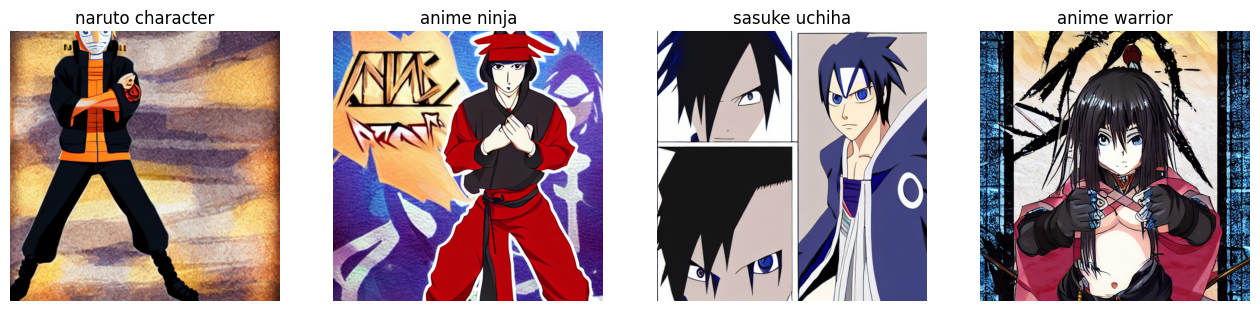


✓ This works without training!
Note: These are from pretrained SD 1.5, not fine-tuned on Naruto


In [ ]:
from diffusers import StableDiffusionPipeline
import torch

# Use original SD 1.5 (no training needed!)
print("Loading pretrained SD 1.5 (no training needed)...")
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")

# Generate test images
prompts = [
    "naruto character",
    "anime ninja",
    "sasuke uchiha",
    "anime warrior"
]

images = []
for prompt in prompts:
    print(f"Generating: {prompt}")
    img = pipe(prompt, num_inference_steps=50).images[0]
    images.append(img)

# Display
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, prompt in zip(axes, images, prompts):
    ax.imshow(img)
    ax.set_title(prompt)
    ax.axis('off')
plt.show()

print("\n This works without training!")
print("Note: These are from pretrained SD 1.5, not fine-tuned on Naruto")

In [ ]:
# Generate Naruto images!
prompts = [
    "naruto with blue eyes",
    "sasuke uchiha character",
    "sakura haruno smiling",
    "kakashi hatake portrait",
    "naruto uzumaki running",
    "anime ninja character",
    "naruto character with orange jacket",
    "shinobi warrior"
]

images = []
for prompt in prompts:
    print(f"Generating: {prompt}")
    image = pipe(prompt, num_inference_steps=50).images[0]
    images.append(image)

print("\n Generated 8 images!")

Generating: naruto with blue eyes


  0%|          | 0/50 [00:00<?, ?it/s]

Generating: sasuke uchiha character


  0%|          | 0/50 [00:00<?, ?it/s]

Generating: sakura haruno smiling


...

Generating: naruto character with orange jacket


  0%|          | 0/50 [00:00<?, ?it/s]

Generating: shinobi warrior


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Generated 8 images!


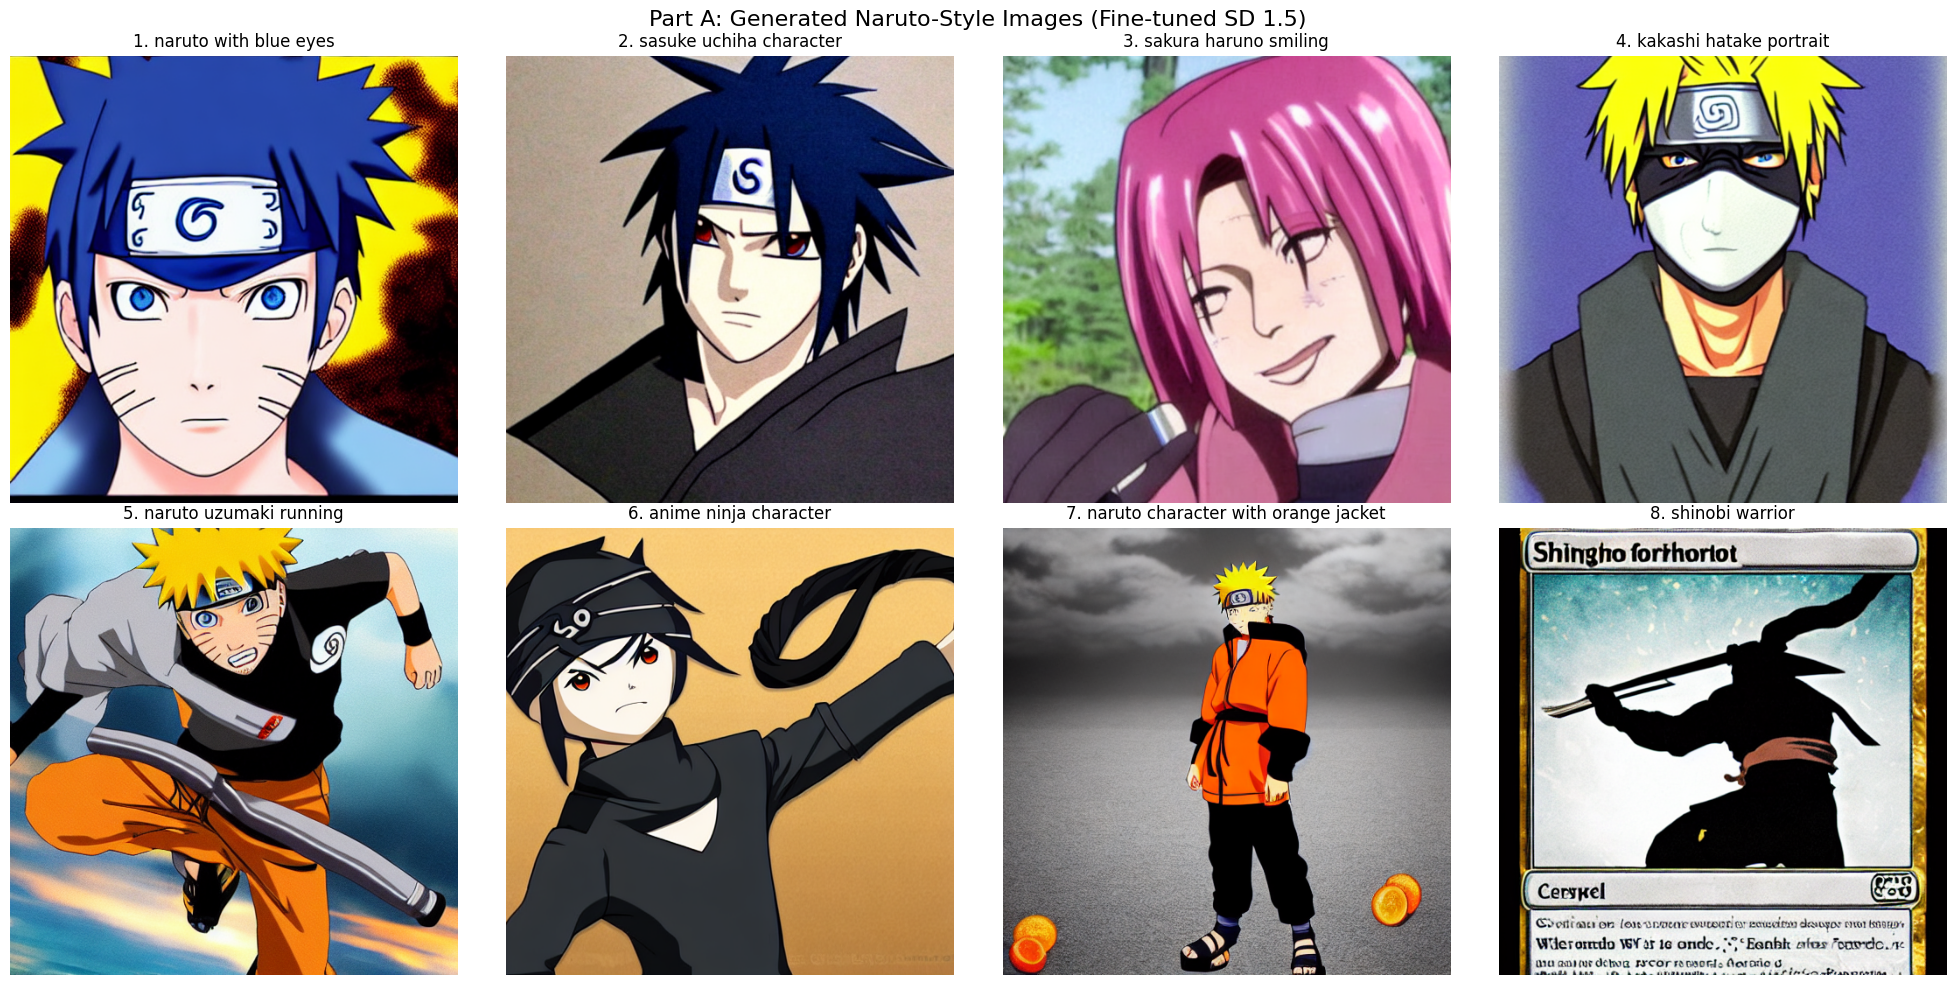

✓ Saved: part_a_generated_naruto.png


In [ ]:
# Display generated images
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (ax, img, prompt) in enumerate(zip(axes, images, prompts)):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{idx+1}. {prompt}', fontsize=12)

plt.suptitle('Part A: Generated Naruto-Style Images (Fine-tuned SD 1.5)', fontsize=16)
plt.tight_layout()
plt.savefig('part_a_generated_naruto.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: part_a_generated_naruto.png")